In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import pandas as pd
from wordcloud import WordCloud,STOPWORDS
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from nltk import word_tokenize
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [17]:
tweet_data = pd.read_csv("/Users/shokoufehnaseri/Library/CloudStorage/OneDrive-Personal/Master-Thesis/Dataset/processed/cleaned_tweets_labelled.csv")

In [18]:
tweet_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            5000 non-null   int64 
 1   created_at    5000 non-null   object
 2   text          5000 non-null   object
 3   sentiment     1300 non-null   object
 4   Text_Cleaned  4997 non-null   object
dtypes: int64(1), object(4)
memory usage: 195.4+ KB


In [19]:
tweet_data['Text_Cleaned'] = tweet_data['Text_Cleaned'].fillna('')


In [20]:
tweet_data.head()

,id,created_at,text,sentiment,Text_Cleaned
0,77522,2020-04-15 01:03:46+00:00,"RT @RobertBeadles: Yo💥\nEnter to WIN 1,000 Mon...",positive,robertbeadles yo enter win monarch tokens cras...
1,661634,2020-06-25 06:20:06+00:00,#SriLanka surcharge on fuel removed!\n⛽📉\nThe ...,negative,srilanka surcharge fuel removed surcharge rs i...
2,413231,2020-06-04 15:41:45+00:00,Net issuance increases to fund fiscal programs...,positive,net issuance increases fund fiscal programs gt...
3,760262,2020-07-03 19:39:35+00:00,RT @bentboolean: How much of Amazon's traffic ...,positive,bentboolean much amazons traffic served fastly...
4,830153,2020-07-09 14:39:14+00:00,$AMD Ryzen 4000 desktop CPUs looking ‘great’ a...,positive,ryzen desktop cpus looking great track launch ...


In [21]:
# Split into labeled and unlabeled data
labeled_data = tweet_data[tweet_data["sentiment"].notna()]
unlabeled_data = tweet_data[tweet_data["sentiment"].isna()]

In [22]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
#Weakly label the 3,700 unlabeled tweets using VADER
analyzer = SentimentIntensityAnalyzer()
def vader_label(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

unlabeled_data['sentiment'] = unlabeled_data['Text_Cleaned'].apply(vader_label)
unlabeled_data = unlabeled_data[['Text_Cleaned', 'sentiment']].rename(columns={'Text_Cleaned': 'text'})

/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_6287/580004080.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unlabeled_data['sentiment'] = unlabeled_data['Text_Cleaned'].apply(vader_label)


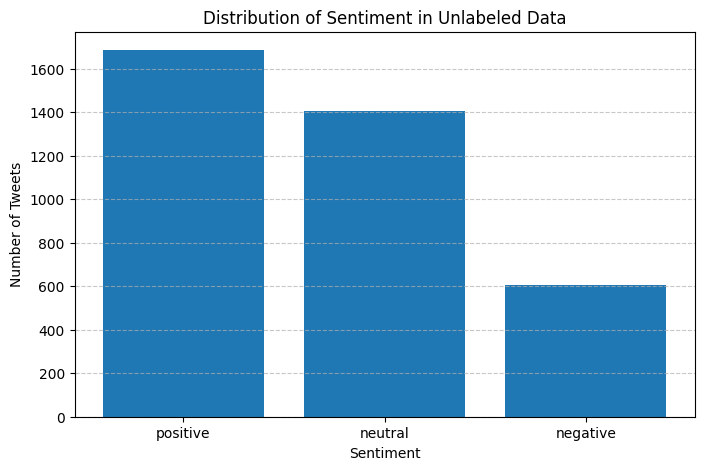

In [23]:
import matplotlib.pyplot as plt

# Count the number of each sentiment label
sentiment_counts = unlabeled_data['sentiment'].value_counts()

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.title('Distribution of Sentiment in Unlabeled Data')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


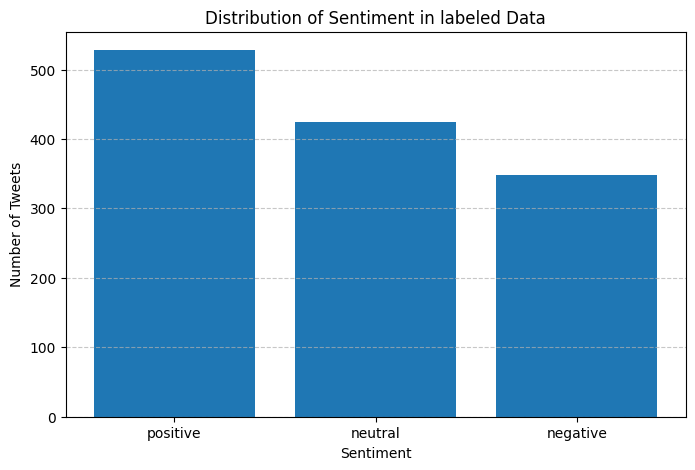

In [24]:
import matplotlib.pyplot as plt

# Count the number of each sentiment label
sentiment_counts = labeled_data['sentiment'].value_counts()

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.title('Distribution of Sentiment in labeled Data')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [25]:
# Step 3: Prepare labeled data
labeled_data = labeled_data[['Text_Cleaned', 'sentiment']].rename(columns={'Text_Cleaned': 'text'})

# Encode sentiment labels numerically for training
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
unlabeled_data['label'] = unlabeled_data['sentiment'].map(label_map)
labeled_data['label'] = labeled_data['sentiment'].map(label_map)

In [28]:
# --- Step 1: Imports and Setup ---

from sklearn.metrics import classification_report, accuracy_score
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.utils import resample
import torch
import pandas as pd

# --- Step 2: Load and Balance Weakly Labeled Data ---

# Load your weakly labeled dataset (assuming it's a DataFrame)
weak_df = unlabeled_data

# Balance the dataset by oversampling minority classes
positive = weak_df[weak_df['label'] == 2]
neutral = weak_df[weak_df['label'] == 1]
negative = weak_df[weak_df['label'] == 0]

neutral_upsampled = resample(neutral, replace=True, n_samples=len(positive), random_state=42)
negative_upsampled = resample(negative, replace=True, n_samples=len(positive), random_state=42)

weak_df_balanced = pd.concat([positive, neutral_upsampled, negative_upsampled])

# Tokenizer
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-tone')

def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

# Tokenize
weak_ds = Dataset.from_pandas(weak_df_balanced, preserve_index=False)
weak_ds = weak_ds.map(tokenize, batched=True)
weak_ds = weak_ds.remove_columns(['text', 'sentiment'])
weak_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# Train/Test split
weak_ds = weak_ds.train_test_split(test_size=0.1, seed=42)

# --- Step 3: Fine-tune on Weakly Labeled Data ---

model = BertForSequenceClassification.from_pretrained('yiyanghkust/finbert-tone', num_labels=3)

training_args = TrainingArguments(
    output_dir='./results_weak',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    #evaluation_strategy='epoch',
    #save_strategy='epoch',
    logging_dir='./logs',
    logging_steps=10,
    #load_best_model_at_end=True,
    #metric_for_best_model='accuracy',
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    report = classification_report(labels, preds, output_dict=True)
    return {"accuracy": acc, "f1": report['weighted avg']['f1-score']}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=weak_ds['train'],
    eval_dataset=weak_ds['test'],
    compute_metrics=compute_metrics
)

trainer.train()

# Save intermediate model
model.save_pretrained('./finbert_weak_finetuned')
tokenizer.save_pretrained('./finbert_weak_finetuned')

# --- Step 4: Load and Fine-tune on Gold Dataset ---

# Load gold dataset
gold_df = labeled_data

# Tokenize
gold_ds = Dataset.from_pandas(gold_df, preserve_index=False)
gold_ds = gold_ds.map(tokenize, batched=True)
gold_ds = gold_ds.remove_columns(['text', 'sentiment'])
gold_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

gold_ds = gold_ds.train_test_split(test_size=0.2, seed=42)

# Load intermediate model
model = BertForSequenceClassification.from_pretrained('./finbert_weak_finetuned')

training_args_gold = TrainingArguments(
    output_dir='./results_gold',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    #evaluation_strategy='epoch',
    #save_strategy='epoch',
    logging_dir='./logs_gold',
    logging_steps=10,
    #load_best_model_at_end=True,
    #metric_for_best_model='accuracy',
)

trainer_gold = Trainer(
    model=model,
    args=training_args_gold,
    train_dataset=gold_ds['train'],
    eval_dataset=gold_ds['test'],
    compute_metrics=compute_metrics
)

trainer_gold.train()

# --- Step 5: Evaluate and Save Final Model ---

trainer_gold.evaluate()

# Save final fine-tuned model
model.save_pretrained('./finbert_final_finetuned')
tokenizer.save_pretrained('./finbert_final_finetuned')

# This final model can now be loaded and used on the 4 million unseen tweets!


Map:   0%|          | 0/5058 [00:00<?, ? examples/s]

Step,Training Loss
10,2.679200
20,1.385800
30,1.219100
40,1.391000
50,1.158200
60,1.119200
70,1.066000
80,0.946200
90,0.959600
100,0.980800


Map:   0%|          | 0/1300 [00:00<?, ? examples/s]

Step,Training Loss
10,1.829700
20,1.238200
30,1.145500
40,0.911000
50,0.864300
60,0.972500
70,0.583400
80,0.416100
90,0.411800
100,0.442500


('./finbert_final_finetuned/tokenizer_config.json',
 './finbert_final_finetuned/special_tokens_map.json',
 './finbert_final_finetuned/vocab.txt',
 './finbert_final_finetuned/added_tokens.json')

In [29]:
trainer_gold.evaluate()


{'eval_loss': 1.6833529472351074,
 'eval_accuracy': 0.7153846153846154,
 'eval_f1': 0.71406007770794,
 'eval_runtime': 3.5179,
 'eval_samples_per_second': 73.909,
 'eval_steps_per_second': 4.832,
 'epoch': 5.0}

In [30]:
model.save_pretrained('./finbert_final_finetuned')
tokenizer.save_pretrained('./finbert_final_finetuned')


('./finbert_final_finetuned/tokenizer_config.json',
 './finbert_final_finetuned/special_tokens_map.json',
 './finbert_final_finetuned/vocab.txt',
 './finbert_final_finetuned/added_tokens.json')